In [2]:
!pip install mlflow dagshub lightgbm -q

import os
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
os.environ["MLFLOW_TRACKING_PASSWORD"] = user_secrets.get_secret("DAGSHUB_TOKEN")
os.environ["MLFLOW_TRACKING_USERNAME"] = user_secrets.get_secret("DAGSHUB_USERNAME")

import mlflow
mlflow.set_tracking_uri("https://dagshub.com/llikl23/house-prices-mlflow.mlflow")
mlflow.set_experiment("house-prices-experiment")

print("MLflow connected!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 73.0 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import pandas as pd

DATA_DIR = "/kaggle/input/competitions/house-prices-advanced-regression-techniques"

train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
sample_submission = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Target: SalePrice (min={train['SalePrice'].min()}, max={train['SalePrice'].max()})")

train.head()

Train shape: (1460, 81)
Test shape:  (1459, 80)
Target: SalePrice (min=34900, max=755000)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# EDA

ამ სექციაში უბრალოდ ვიკვლევ მონაცემებს ტრანსფორმაციების გარეშე, მათ ტიპებს, რომლებს აქვს ნულოვანი და არარიცხვითი მნიშვნელობები, როგორია ფასის განაწილება, სიმეტრიული თუ skewed, რომელი რიცხვითი მონაცემები კორელირებენ ყველაზე მეტად target-თან, გვაქვს თუ არა outlier-ები.

In [4]:
import numpy as np

print("=== DTYPE BREAKDOWN ===")
print(train.dtypes.value_counts())

num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(include=["object"]).columns.tolist()
print(f"\nNumerical columns: {len(num_cols)}  (includes Id and SalePrice)")
print(f"Categorical columns: {len(cat_cols)}")

=== DTYPE BREAKDOWN ===
object     43
int64      35
float64     3
Name: count, dtype: int64

Numerical columns: 38  (includes Id and SalePrice)
Categorical columns: 43


In [5]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = (
    pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
    .query("n_missing > 0")
    .sort_values("pct_missing", ascending=False)
)
print(f"Total columns with missing values: {len(missing_df)}\n")
print(missing_df.head(20))

Total columns with missing values: 19

              n_missing  pct_missing
PoolQC             1453        99.52
MiscFeature        1406        96.30
Alley              1369        93.77
Fence              1179        80.75
MasVnrType          872        59.73
FireplaceQu         690        47.26
LotFrontage         259        17.74
GarageType           81         5.55
GarageYrBlt          81         5.55
GarageFinish         81         5.55
GarageQual           81         5.55
GarageCond           81         5.55
BsmtExposure         38         2.60
BsmtFinType2         38         2.60
BsmtQual             37         2.53
BsmtCond             37         2.53
BsmtFinType1         37         2.53
MasVnrArea            8         0.55
Electrical            1         0.07


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness (raw):        1.883
Skewness (log1p):      0.121


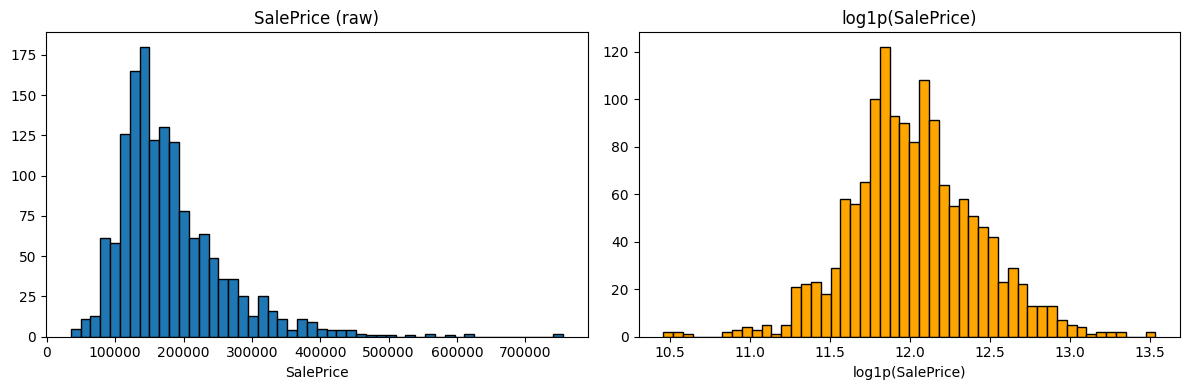

In [6]:
import matplotlib.pyplot as plt

print(train["SalePrice"].describe())
print(f"\nSkewness (raw):        {train['SalePrice'].skew():.3f}")
print(f"Skewness (log1p):      {np.log1p(train['SalePrice']).skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train["SalePrice"], bins=50, edgecolor="black")
axes[0].set_title("SalePrice (raw)")
axes[0].set_xlabel("SalePrice")
axes[1].hist(np.log1p(train["SalePrice"]), bins=50, edgecolor="black", color="orange")
axes[1].set_title("log1p(SalePrice)")
axes[1].set_xlabel("log1p(SalePrice)")
plt.tight_layout()
plt.show()

In [7]:
corr = train[num_cols].corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)

print("=== TOP 15 POSITIVE ===")
print(corr.head(15))
print("\n=== BOTTOM 5 (most negative) ===")
print(corr.tail(5))

=== TOP 15 POSITIVE ===
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64

=== BOTTOM 5 (most negative) ===
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


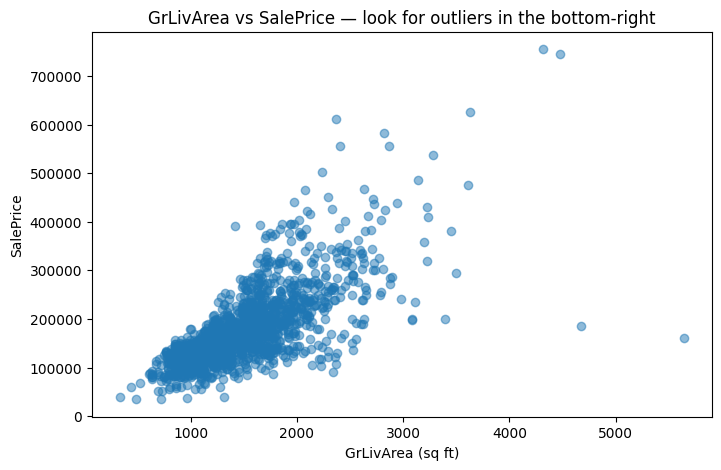

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(train["GrLivArea"], train["SalePrice"], alpha=0.5)
plt.xlabel("GrLivArea (sq ft)")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice — look for outliers in the bottom-right")
plt.show()

# DATA SEPARATION
ამ ნაწილში ვაცალკევებ target და feature ცვლადებს, და ვყოფ train data-ს train და validation ნაწილებად 80/20 თანაფარდობით

In [9]:
from sklearn.model_selection import train_test_split

y = train["SalePrice"]
y_log = np.log1p(y)
X = train.drop(columns=["Id", "SalePrice"])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X_train, X_val, y_train, y_val = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=42,
)

print(f"\nX_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_val:   {y_val.shape}")

X shape: (1460, 79)
y shape: (1460,)

X_train: (1168, 79)
X_val:   (292, 79)
y_train: (1168,)
y_val:   (292,)


# CLEANING
ამ ნაწილში ვაშორებ outlier-ებს, გარდავქმნი კატეგორიულ და ცარიელ ცვლადებს რიცხვებად

In [10]:
outlier_mask = (X_train["GrLivArea"] > 4000) & (y_train < np.log1p(200000))
print(f"Outliers found in training set: {outlier_mask.sum()}")

X_train = X_train[~outlier_mask].reset_index(drop=True)
y_train = y_train[~outlier_mask].reset_index(drop=True)

print(f"X_train shape after removal: {X_train.shape}")
print(f"y_train shape after removal: {y_train.shape}")

Outliers found in training set: 2
X_train shape after removal: (1166, 79)
y_train shape after removal: (1166,)


In [11]:
none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",
]
zero_cols = ["GarageYrBlt", "MasVnrArea"]

for col in none_cols:
    X_train[col] = X_train[col].fillna("None")
    X_val[col] = X_val[col].fillna("None")

for col in zero_cols:
    X_train[col] = X_train[col].fillna(0)
    X_val[col] = X_val[col].fillna(0)

lot_frontage_medians = X_train.groupby("Neighborhood")["LotFrontage"].median()
global_lot_median = X_train["LotFrontage"].median()

X_train["LotFrontage"] = X_train["LotFrontage"].fillna(
    X_train["Neighborhood"].map(lot_frontage_medians)
)
X_val["LotFrontage"] = X_val["LotFrontage"].fillna(
    X_val["Neighborhood"].map(lot_frontage_medians)
)
X_val["LotFrontage"] = X_val["LotFrontage"].fillna(global_lot_median)

electrical_mode = X_train["Electrical"].mode()[0]
X_train["Electrical"] = X_train["Electrical"].fillna(electrical_mode)
X_val["Electrical"] = X_val["Electrical"].fillna(electrical_mode)

print("Remaining nulls in X_train:", X_train.isnull().sum().sum())
print("Remaining nulls in X_val:  ", X_val.isnull().sum().sum())

Remaining nulls in X_train: 0
Remaining nulls in X_val:   0


In [12]:
from sklearn.preprocessing import OneHotEncoder

quality_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

ordinal_maps = {
    "ExterQual":    quality_map,
    "ExterCond":    quality_map,
    "BsmtQual":     quality_map,
    "BsmtCond":     quality_map,
    "HeatingQC":    quality_map,
    "KitchenQual":  quality_map,
    "FireplaceQu":  quality_map,
    "GarageQual":   quality_map,
    "GarageCond":   quality_map,
    "PoolQC":       quality_map,
    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "Functional":   {"Sal": 0, "Sev": 1, "Maj2": 2, "Maj1": 3, "Mod": 4, "Min2": 5, "Min1": 6, "Typ": 7},
    "LotShape":     {"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3},
    "LandSlope":    {"Sev": 0, "Mod": 1, "Gtl": 2},
    "PavedDrive":   {"N": 0, "P": 1, "Y": 2},
    "Street":       {"Grvl": 0, "Pave": 1},
    "Alley":        {"None": 0, "Grvl": 1, "Pave": 2},
    "CentralAir":   {"N": 0, "Y": 1},
    "Utilities":    {"ELO": 0, "NoSeWa": 1, "NoSewr": 2, "AllPub": 3},
}

for col, mapping in ordinal_maps.items():
    X_train[col] = X_train[col].map(mapping)
    X_val[col] = X_val[col].map(mapping)

nominal_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
print(f"Nominal columns to one-hot encode: {len(nominal_cols)}")

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(X_train[nominal_cols])

train_ohe = pd.DataFrame(
    ohe.transform(X_train[nominal_cols]),
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X_train.index,
)
val_ohe = pd.DataFrame(
    ohe.transform(X_val[nominal_cols]),
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X_val.index,
)

X_train = pd.concat([X_train.drop(columns=nominal_cols), train_ohe], axis=1)
X_val = pd.concat([X_val.drop(columns=nominal_cols), val_ohe], axis=1)

print(f"X_train shape after encoding: {X_train.shape}")
print(f"X_val shape after encoding:   {X_val.shape}")
print(f"Remaining object columns: {(X_train.dtypes == 'object').sum()}")
print(f"Remaining NaN:            {X_train.isnull().sum().sum()}")

Nominal columns to one-hot encode: 21
X_train shape after encoding: (1166, 222)
X_val shape after encoding:   (292, 222)
Remaining object columns: 0
Remaining NaN:            0


# FEATURE ENGINEERING
ამ ნაწილში შევეცდები არსებული თვისებებისგან რაღაც ახალი თვისებები გამოვიყვანოთ და დავამატოთ, რომლებიც შესაძლოა რელევანტური იყოს ფასის დადგენისთვის

In [13]:
for df in [X_train, X_val]:
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["TotalBathrooms"] = (
        df["FullBath"] + 0.5 * df["HalfBath"]
        + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]
    )
    df["TotalPorchSF"] = (
        df["OpenPorchSF"] + df["EnclosedPorch"]
        + df["3SsnPorch"] + df["ScreenPorch"] + df["WoodDeckSF"]
    )
    df["TotalFinishedBsmtSF"] = df["BsmtFinSF1"] + df["BsmtFinSF2"]

    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["YearsSinceRemodel"] = df["YrSold"] - df["YearRemodAdd"]
    df["GarageAge"] = np.where(
        df["GarageYrBlt"] > 0,
        df["YrSold"] - df["GarageYrBlt"],
        0,
    )
    df["IsRemodeled"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)

    df["LivingAreaPerRoom"] = df["GrLivArea"] / df["TotRmsAbvGrd"]

new_features = [
    "TotalSF", "TotalBathrooms", "TotalPorchSF", "TotalFinishedBsmtSF",
    "HouseAge", "YearsSinceRemodel", "GarageAge", "IsRemodeled",
    "LivingAreaPerRoom",
]

print(f"New features added: {len(new_features)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
X_train[new_features].head()

New features added: 9
X_train shape: (1166, 231)
X_val shape:   (292, 231)


,TotalSF,TotalBathrooms,TotalPorchSF,TotalFinishedBsmtSF,HouseAge,YearsSinceRemodel,GarageAge,IsRemodeled,LivingAreaPerRoom
0,2628,2.0,250,922,53,53,53.0,0,262.800000
1,2370,2.5,40,0,16,15,16.0,1,224.428571
2,1592,1.0,492,0,98,58,0.0,1,199.000000
3,2499,2.5,264,569,70,57,68.0,1,252.571429
4,2717,2.0,242,218,86,60,86.0,1,281.833333


# FEATURE SELECTION
ვიყენებთ შემდეგ ტექნიკებს feature-ების შემცირებისთვის: All features (baseline), Variance Threshold, Correlation with Target, Correlation between Features, RFE (Recursive Feature Elimination), Tree-based Feature Importance, Lasso (L1 Regularization)

In [14]:
features_all = X_train.columns.tolist()
print(f"features_all: {len(features_all)} columns")

features_all: 231 columns


In [15]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train)
features_variance = X_train.columns[vt.get_support()].tolist()

dropped = set(features_all) - set(features_variance)
print(f"features_variance: {len(features_variance)} columns  (dropped {len(dropped)})")
print(f"Examples of dropped near-constant columns: {list(dropped)[:10]}")

features_variance: 168 columns  (dropped 63)
Examples of dropped near-constant columns: ['Exterior1st_ImStucc', 'Electrical_FuseP', 'Condition1_RRNn', 'RoofStyle_Shed', 'MSZoning_C (all)', 'SaleType_ConLw', 'Neighborhood_MeadowV', 'Exterior2nd_AsphShn', 'RoofMatl_WdShngl', 'Condition2_RRNn']


In [16]:
corr_with_target = X_train.corrwith(y_train).abs().sort_values(ascending=False)
features_corr_target = corr_with_target[corr_with_target > 0.05].index.tolist()

print(f"features_corr_target: {len(features_corr_target)} columns")
print(f"Dropped {len(features_all) - len(features_corr_target)} features with |corr| <= 0.05")
print(f"\nTop 10 by correlation:")
print(corr_with_target.head(10))

features_corr_target: 158 columns
Dropped 73 features with |corr| <= 0.05

Top 10 by correlation:
TotalSF           0.822166
OverallQual       0.813304
GrLivArea         0.719381
GarageCars        0.684979
KitchenQual       0.670664
ExterQual         0.664352
TotalBathrooms    0.663966
GarageArea        0.661341
TotalBsmtSF       0.641135
BsmtQual          0.623818
dtype: float64


In [17]:
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []
to_drop = set()
for col in upper.columns:
    correlated = upper.index[upper[col] > 0.9].tolist()
    for other in correlated:
        if other in to_drop or col in to_drop:
            continue
        if corr_with_target.get(col, 0) >= corr_with_target.get(other, 0):
            to_drop.add(other)
            high_corr_pairs.append((col, other, upper.loc[other, col]))
        else:
            to_drop.add(col)
            high_corr_pairs.append((other, col, upper.loc[other, col]))

features_corr_pairs = [c for c in features_all if c not in to_drop]

print(f"features_corr_pairs: {len(features_corr_pairs)} columns  (dropped {len(to_drop)})")
print(f"\nExample dropped pairs (kept, dropped, corr):")
for kept, dropped_col, c in high_corr_pairs[:10]:
    print(f"  kept {kept!r:30}  dropped {dropped_col!r:30}  corr={c:.3f}")

features_corr_pairs: 216 columns  (dropped 15)

Example dropped pairs (kept, dropped, corr):
  kept 'GarageQual'                    dropped 'GarageYrBlt'                   corr=0.946
  kept 'GarageQual'                    dropped 'GarageCond'                    corr=0.959
  kept 'PoolQC'                        dropped 'PoolArea'                      corr=0.919
  kept 'RoofStyle_Hip'                 dropped 'RoofStyle_Gable'               corr=0.933
  kept 'RoofStyle_Flat'                dropped 'RoofMatl_Tar&Grv'              corr=0.904
  kept 'Exterior2nd_CBlock'            dropped 'Exterior1st_CBlock'            corr=1.000
  kept 'Exterior1st_CemntBd'           dropped 'Exterior2nd_CmentBd'           corr=0.964
  kept 'Exterior1st_MetalSd'           dropped 'Exterior2nd_MetalSd'           corr=0.973
  kept 'Exterior2nd_VinylSd'           dropped 'Exterior1st_VinylSd'           corr=0.974
  kept 'GarageQual'                    dropped 'GarageType_None'               corr=0.942


In [18]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

scaler_for_rfe = StandardScaler()
X_train_scaled_rfe = scaler_for_rfe.fit_transform(X_train)

rfe = RFE(
    estimator=Ridge(alpha=1.0, random_state=42),
    n_features_to_select=80,
    step=10,
)
rfe.fit(X_train_scaled_rfe, y_train)

features_rfe = X_train.columns[rfe.support_].tolist()

print(f"features_rfe: {len(features_rfe)} columns  (dropped {len(features_all) - len(features_rfe)})")
print(f"\nFirst 15 RFE-selected features:")
print(features_rfe[:15])

features_rfe: 80 columns  (dropped 151)

First 15 RFE-selected features:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'ExterCond', 'BsmtQual', 'BsmtExposure', 'BsmtFinSF1', 'TotalBsmtSF', 'HeatingQC', 'CentralAir', '2ndFlrSF', 'GrLivArea']


In [19]:
from lightgbm import LGBMRegressor

lgbm_selector = LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)
lgbm_selector.fit(X_train, y_train)

importances = pd.Series(
    lgbm_selector.feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False)

top_n = 100
features_tree_importance = importances.head(top_n).index.tolist()

print(f"features_tree_importance: {len(features_tree_importance)} columns  (top {top_n} by LightGBM importance)")
print(f"\nTop 15 most important features:")
print(importances.head(15))
print(f"\nBottom 5 (nearly unused):")
print(importances.tail(5))

features_tree_importance: 100 columns  (top 100 by LightGBM importance)

Top 15 most important features:
TotalSF              318
LotArea              309
GarageArea           287
GrLivArea            284
TotalPorchSF         253
LivingAreaPerRoom    249
1stFlrSF             245
BsmtUnfSF            245
TotalBsmtSF          218
OpenPorchSF          159
MoSold               155
MasVnrArea           152
LotFrontage          151
GarageYrBlt          144
BsmtFinSF1           136
dtype: int32

Bottom 5 (nearly unused):
MiscFeature_None         0
SaleCondition_Partial    0
SaleCondition_Family     0
SaleCondition_AdjLand    0
SaleCondition_Alloca     0
dtype: int32


In [20]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

scaler_for_lasso = StandardScaler()
X_train_scaled_lasso = scaler_for_lasso.fit_transform(X_train)

lasso = LassoCV(cv=5, random_state=42, max_iter=5000, n_jobs=-1)
lasso.fit(X_train_scaled_lasso, y_train)

lasso_coefs = pd.Series(lasso.coef_, index=X_train.columns)
features_lasso = lasso_coefs[lasso_coefs != 0].index.tolist()

print(f"features_lasso: {len(features_lasso)} columns  (dropped {len(features_all) - len(features_lasso)})")
print(f"Lasso alpha chosen by CV: {lasso.alpha_:.6f}")
print(f"\nTop 10 features by |coefficient|:")
print(lasso_coefs.abs().sort_values(ascending=False).head(10))

features_lasso: 101 columns  (dropped 130)
Lasso alpha chosen by CV: 0.002996

Top 10 features by |coefficient|:
GrLivArea               0.082927
TotalSF                 0.072951
OverallQual             0.069939
HouseAge                0.037840
OverallCond             0.036826
Functional              0.024205
BsmtFinSF1              0.020868
GarageArea              0.017762
Neighborhood_Crawfor    0.017635
YearsSinceRemodel       0.016425
dtype: float64


In [28]:
feature_sets = {
    "all":              features_all,
    "variance":         features_variance,
    "corr_target":      features_corr_target,
    "corr_pairs":       features_corr_pairs,
    "rfe":              features_rfe,
    "tree_importance":  features_tree_importance,
    "lasso":            features_lasso,
}

print("=== Feature selection summary ===")
for name, feats in feature_sets.items():
    print(f"  {name:20s}  {len(feats):4d} features")

=== Feature selection summary ===
  all                    231 features
  variance               168 features
  corr_target            158 features
  corr_pairs             216 features
  rfe                     80 features
  tree_importance        100 features
  lasso                  101 features


# TRAINING
შევუშვათ ყველა მიღებული დატასეტი შემდეგ 4 მოდელში: Ridge, Lasso, Decision Tree, Random Forest

In [29]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def train_and_log(model_name, model, feature_set_name, features, needs_scaling):
    X_tr = X_train[features]
    X_va = X_val[features]

    if needs_scaling:
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model),
        ])
    else:
        pipeline = Pipeline([("model", model)])

    run_name = f"{model_name}__{feature_set_name}"
    with mlflow.start_run(run_name=run_name):
        pipeline.fit(X_tr, y_train)

        train_pred = pipeline.predict(X_tr)
        val_pred = pipeline.predict(X_va)

        train_rmse = rmse(y_train, train_pred)
        val_rmse = rmse(y_val, val_pred)
        gap = val_rmse - train_rmse

        mlflow.log_param("model", model_name)
        mlflow.log_param("feature_set", feature_set_name)
        mlflow.log_param("n_features", len(features))
        mlflow.log_param("needs_scaling", needs_scaling)
        for k, v in model.get_params().items():
            mlflow.log_param(f"hp_{k}", v)

        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("val_rmse", val_rmse)
        mlflow.log_metric("overfit_gap", gap)

        mlflow.sklearn.log_model(pipeline, "model")

        print(f"  {feature_set_name:18s}  train={train_rmse:.4f}  val={val_rmse:.4f}  gap={gap:+.4f}")

        return val_rmse

In [30]:
from sklearn.linear_model import Ridge

print("=== Ridge ===")
for fs_name, fs_features in feature_sets.items():
    model = Ridge(alpha=1.0, random_state=42)
    train_and_log("Ridge", model, fs_name, fs_features, needs_scaling=True)

=== Ridge ===


2026/04/10 13:56:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 13:56:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  all                 train=0.0909  val=0.1235  gap=+0.0326
🏃 View run Ridge__all at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/37045732a99d4b0b9c27d107dbeccb87
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


2026/04/10 13:56:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 13:56:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  variance            train=0.0948  val=0.1204  gap=+0.0257
🏃 View run Ridge__variance at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/73350dd596b9441fb03907eec3ebb2e4
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


...

  rfe                 train=0.0954  val=0.1225  gap=+0.0271
🏃 View run Ridge__rfe at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/8a4890e6efee43b3848c1777c3ba6609
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


2026/04/10 13:58:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 13:59:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  tree_importance     train=0.1001  val=0.1303  gap=+0.0301
🏃 View run Ridge__tree_importance at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/5382579041044a06bbaf47170af9fad0
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


2026/04/10 13:59:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 13:59:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  lasso               train=0.0941  val=0.1211  gap=+0.0271
🏃 View run Ridge__lasso at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/76b4e57005034900bdbc911cf1b85d69
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


In [31]:
from sklearn.linear_model import Lasso

print("=== Lasso ===")
for fs_name, fs_features in feature_sets.items():
    model = Lasso(alpha=0.001, random_state=42, max_iter=10000)
    train_and_log("Lasso", model, fs_name, fs_features, needs_scaling=True)

=== Lasso ===


2026/04/10 14:01:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 14:01:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  all                 train=0.0926  val=0.1198  gap=+0.0272
🏃 View run Lasso__all at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/97f439fdfb7949a48c3d764c01b442a9
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


2026/04/10 14:01:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 14:01:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  variance            train=0.0972  val=0.1262  gap=+0.0290
🏃 View run Lasso__variance at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/714c0ea5296a483a9cd9a3901819d908
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


...

  rfe                 train=0.0963  val=0.1210  gap=+0.0247
🏃 View run Lasso__rfe at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/02dcd13f87b44ef7a158bf378002d213
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


2026/04/10 14:04:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 14:04:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  tree_importance     train=0.1010  val=0.1287  gap=+0.0277
🏃 View run Lasso__tree_importance at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/b258052390ec487893c67077e8e900aa
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


2026/04/10 14:04:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 14:04:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  lasso               train=0.0944  val=0.1198  gap=+0.0253
🏃 View run Lasso__lasso at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/39bed4c3654a41d6b02869d245aaed85
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


In [32]:
from sklearn.tree import DecisionTreeRegressor

print("=== DecisionTree ===")
for fs_name, fs_features in feature_sets.items():
    model = DecisionTreeRegressor(random_state=42)
    train_and_log("DecisionTree", model, fs_name, fs_features, needs_scaling=False)

=== DecisionTree ===


2026/04/10 14:05:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 14:06:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  all                 train=0.0000  val=0.1832  gap=+0.1832
🏃 View run DecisionTree__all at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/87999f10f2d0469d88755561280cd473
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


2026/04/10 14:06:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 14:06:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  variance            train=0.0000  val=0.1794  gap=+0.1794
🏃 View run DecisionTree__variance at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/50ed5af91ef54ae69adec89e1d9ff500
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


...

  rfe                 train=0.0000  val=0.2099  gap=+0.2099
🏃 View run DecisionTree__rfe at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/1df5dd514edf4080a8e7d17983982c6f
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


2026/04/10 14:09:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 14:09:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  tree_importance     train=0.0000  val=0.1793  gap=+0.1793
🏃 View run DecisionTree__tree_importance at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/78da38d9dc574e9aa91d76bad458499c
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


2026/04/10 14:09:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 14:09:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  lasso               train=0.0000  val=0.1952  gap=+0.1952
🏃 View run DecisionTree__lasso at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/68c612e68f7c475794f6cbfef3900120
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


In [33]:
from sklearn.ensemble import RandomForestRegressor

print("=== RandomForest ===")
for fs_name, fs_features in feature_sets.items():
    model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    train_and_log("RandomForest", model, fs_name, fs_features, needs_scaling=False)

=== RandomForest ===


2026/04/10 14:12:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 14:12:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  all                 train=0.0503  val=0.1451  gap=+0.0948
🏃 View run RandomForest__all at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/8dd72522d4ec4216ab22134306a45b3e
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


2026/04/10 14:13:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 14:13:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  variance            train=0.0503  val=0.1461  gap=+0.0959
🏃 View run RandomForest__variance at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/9421c1eb09d94e31916b677232c88760
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


...

  rfe                 train=0.0492  val=0.1436  gap=+0.0944
🏃 View run RandomForest__rfe at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/10466a157a6b4bf881b10a37be49870d
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


2026/04/10 14:15:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 14:16:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  tree_importance     train=0.0501  val=0.1468  gap=+0.0968
🏃 View run RandomForest__tree_importance at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/ec4f003c7ee6462dafad7e1d8a38b7a8
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


2026/04/10 14:16:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 14:16:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  lasso               train=0.0494  val=0.1444  gap=+0.0950
🏃 View run RandomForest__lasso at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/c90547e06c2a4ababb93f44a9f762589
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0


In [34]:
best_feature_set_name = "corr_target"
best_features = feature_sets[best_feature_set_name]

X_tr_best = X_train[best_features]
X_va_best = X_val[best_features]

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.001, random_state=42, max_iter=10000)),
])

with mlflow.start_run(run_name="FINAL_Lasso_corr_target") as run:
    final_pipeline.fit(X_tr_best, y_train)
    val_pred = final_pipeline.predict(X_va_best)
    val_rmse_final = rmse(y_val, val_pred)

    mlflow.log_param("model", "Lasso")
    mlflow.log_param("feature_set", best_feature_set_name)
    mlflow.log_param("alpha", 0.001)
    mlflow.log_param("n_features", len(best_features))
    mlflow.log_metric("val_rmse", val_rmse_final)

    mlflow.sklearn.log_model(
        final_pipeline,
        name="model",
        registered_model_name="house-prices-best-model",
    )

    final_run_id = run.info.run_id
    print(f"Val RMSE: {val_rmse_final:.4f}")
    print(f"Registered as 'house-prices-best-model'")
    print(f"Run ID: {final_run_id}")

2026/04/10 14:24:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'house-prices-best-model'.
2026/04/10 14:25:01 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: house-prices-best-model, version 1
Created version '1' of model 'house-prices-best-model'.


Val RMSE: 0.1196
Registered as 'house-prices-best-model'
Run ID: 5bbf5e5e46c140d3b228447f880d160a
🏃 View run FINAL_Lasso_corr_target at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0/runs/5bbf5e5e46c140d3b228447f880d160a
🧪 View experiment at: https://dagshub.com/llikl23/house-prices-mlflow.mlflow/#/experiments/0
